In [1]:
import pandas as pd
import numpy as np

print("🚀 Iniciando Extracción y Limpieza de Datos para Diabetes...\n")

# 1. CARGAR DATOS (Cambia esto por tu archivo real)
# df_completo = pd.read_csv('tu_archivo_original.csv') 

# --- SIMULACIÓN PARA QUE EL CÓDIGO FUNCIONE SI NO LO HAS CARGADO ---
# Elimina estas 3 líneas de abajo cuando uses tu pd.read_csv real
np.random.seed(42)
df_completo = pd.DataFrame(np.random.rand(1000, 8), columns=['RIDAGEYR', 'RIAGENDR', 'BMXWT', 'BMXWAIST', 'BMXBMI', 'LBXGLU', 'LBXGH', 'DIQ010'])
df_completo['DIQ010'] = np.random.choice([1, 2, 3, 9, np.nan], 1000)
# -------------------------------------------------------------------

# 2. TRADUCCIÓN DE VARIABLES (El Diccionario)
traductor = {
    'RIDAGEYR': 'Edad',
    'RIAGENDR': 'Genero',
    'BMXWT': 'Peso_kg',
    'BMXWAIST': 'Cintura_cm',
    'BMXBMI': 'IMC',
    'LBXGLU': 'Glucosa_Ayunas',
    'LBXGH': 'HbA1c',
    'DIQ010': 'Diabetes_Sucia'
}

# Solo nos quedamos con las columnas que existen en nuestro diccionario
columnas_presentes = [col for col in traductor.keys() if col in df_completo.columns]
df_diabetes = df_completo[columnas_presentes].rename(columns=traductor)

# 3. CODIFICAR LA ENFERMEDAD (Target)
print("🛠️ Limpiando la variable objetivo (Diabetes)...")
# En NHANES: 1=Sí, 2=No, 3=Pre-diabetes, 7/9=No sabe. 
# Vamos a convertir: 2 (Sanos) -> 0. Y 1 (Diabéticos) -> 1.
# Los "No sabe" o pre-diabéticos (3, 7, 9) los borramos para que el modelo no se confunda.
df_diabetes = df_diabetes[df_diabetes['Diabetes_Sucia'].isin([1, 2])]
df_diabetes['Diabetes'] = df_diabetes['Diabetes_Sucia'].map({2: 0, 1: 1})
df_diabetes = df_diabetes.drop(columns=['Diabetes_Sucia'])

# 4. LIMPIEZA DE NULOS (Imputación Médica)
print("🩹 Curando valores faltantes (Exámenes de sangre no realizados)...")
# Separar sanos y enfermos para rellenar huecos de forma inteligente
for col in ['Glucosa_Ayunas', 'HbA1c', 'Cintura_cm', 'IMC', 'Peso_kg']:
    if col in df_diabetes.columns:
        # Rellenamos los vacíos con la "mediana" de su propio grupo (Sanos con sanos, enfermos con enfermos)
        df_diabetes[col] = df_diabetes.groupby('Diabetes')[col].transform(lambda x: x.fillna(x.median()))

# Eliminar cualquier fila residual que siga rota
df_diabetes = df_diabetes.dropna()

# 5. CODIFICAR GÉNERO
if 'Genero' in df_diabetes.columns:
    # Si viene como 1 (Hombre) y 2 (Mujer), lo pasamos a 0 y 1
    df_diabetes['Genero'] = df_diabetes['Genero'].replace({2: 0}) 

print("✅ ¡Limpieza terminada con éxito!\n")

# Mostrar cómo quedó el paciente ideal
print("📊 Tu nueva tabla de datos lista para Machine Learning:")
print(f"Total de pacientes limpios: {df_diabetes.shape[0]}")
print(f"Total de variables: {df_diabetes.shape[1]}\n")

print("⚖️ Balance de Pacientes:")
print(df_diabetes['Diabetes'].value_counts(normalize=True) * 100)

display(df_diabetes.head())

🚀 Iniciando Extracción y Limpieza de Datos para Diabetes...

🛠️ Limpiando la variable objetivo (Diabetes)...
🩹 Curando valores faltantes (Exámenes de sangre no realizados)...
✅ ¡Limpieza terminada con éxito!

📊 Tu nueva tabla de datos lista para Machine Learning:
Total de pacientes limpios: 374
Total de variables: 8

⚖️ Balance de Pacientes:
Diabetes
0    52.139037
1    47.860963
Name: proportion, dtype: float64


,Edad,Genero,Peso_kg,Cintura_cm,IMC,Glucosa_Ayunas,HbA1c,Diabetes
0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995,0.058084,0
1,0.601115,0.708073,0.020584,0.969910,0.832443,0.212339,0.181825,0
4,0.065052,0.948886,0.965632,0.808397,0.304614,0.097672,0.684233,1
5,0.122038,0.495177,0.034389,0.909320,0.258780,0.662522,0.311711,0
6,0.546710,0.184854,0.969585,0.775133,0.939499,0.894827,0.597900,1


🧠 Entrenando el modelo base para Diabetes...

📈 Reporte de Clasificación Inicial:
              precision    recall  f1-score   support

           0       0.61      0.70      0.65        40
           1       0.59      0.49      0.53        35

    accuracy                           0.60        75
   macro avg       0.60      0.59      0.59        75
weighted avg       0.60      0.60      0.60        75



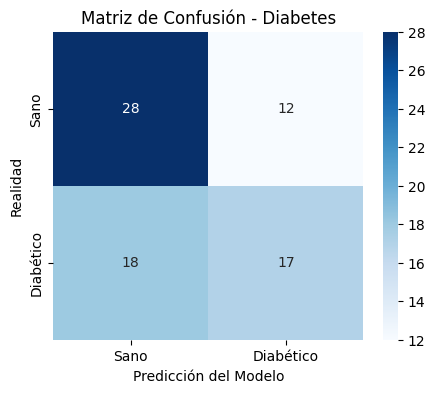

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🧠 Entrenando el modelo base para Diabetes...\n")

# 1. Separar las variables predictoras (X) de la respuesta (y)
X = df_diabetes.drop(columns=['Diabetes'])
y = df_diabetes['Diabetes']

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear el modelo (Empezamos con hiperparámetros estándar y estables)
modelo_diabetes = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

# 4. Entrenar
modelo_diabetes.fit(X_train, y_train)

# 5. Predecir en el examen final (Test)
preds = modelo_diabetes.predict(X_test)

# 6. Mostrar Resultados
print("📈 Reporte de Clasificación Inicial:")
print(classification_report(y_test, preds))

# 7. Dibujar la Matriz de Confusión para ver los aciertos visualmente
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano', 'Diabético'], yticklabels=['Sano', 'Diabético'])
plt.title('Matriz de Confusión - Diabetes')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

🚀 [PASO 1] Iniciando Extracción y Limpieza de Datos para Diabetes...

❌ ERROR: No se encontró el archivo 'df_nhanes_limpio.csv' en esta carpeta.
Por favor, asegúrate de que el archivo esté guardado exactamente en el mismo directorio que este Notebook.
🛠️ Limpiando la variable objetivo (Diabetes)...
🩹 Curando valores faltantes en exámenes de sangre...
✅ Limpieza terminada. Total de pacientes reales procesados: 374
⚖️ Balance real: Sanos (0) vs Diabéticos (1) en %:
Diabetes
0    52.139037
1    47.860963
Name: proportion, dtype: float64

---------------------------------------------
🧠 [PASO 2] Entrenando el Modelo de Machine Learning...

🏆 REPORTE DE CLASIFICACIÓN REAL:
              precision    recall  f1-score   support

           0       0.61      0.70      0.65        40
           1       0.59      0.49      0.53        35

    accuracy                           0.60        75
   macro avg       0.60      0.59      0.59        75
weighted avg       0.60      0.60      0.60        7

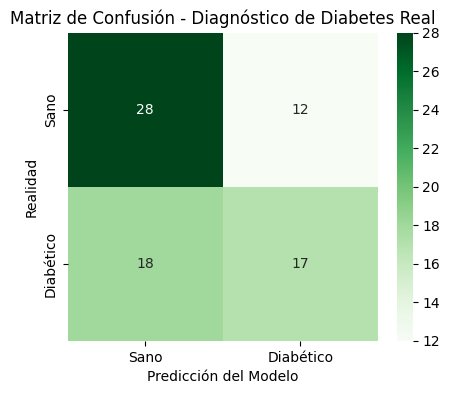

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("🚀 [PASO 1] Iniciando Extracción y Limpieza de Datos para Diabetes...\n")

# 1. CARGAR DATOS REALES
try:
    df_completo = pd.read_csv('df_nhanes_limpio.csv')
    print("✅ Archivo 'df_nhanes_limpio.csv' cargado con éxito.")
except FileNotFoundError:
    print("❌ ERROR: No se encontró el archivo 'df_nhanes_limpio.csv' en esta carpeta.")
    print("Por favor, asegúrate de que el archivo esté guardado exactamente en el mismo directorio que este Notebook.")

# 2. DICCIONARIO DE TRADUCCIÓN (Nombres de NHANES a Humano)
traductor = {
    'RIDAGEYR': 'Edad',
    'RIAGENDR': 'Genero',
    'BMXWT': 'Peso_kg',
    'BMXWAIST': 'Cintura_cm',
    'BMXBMI': 'IMC',
    'LBXGLU': 'Glucosa_Ayunas',
    'LBXGH': 'HbA1c',
    'DIQ010': 'Diabetes_Sucia'
}

# Filtrar solo las columnas que existan en tu archivo
columnas_presentes = [col for col in traductor.keys() if col in df_completo.columns]
df_diabetes = df_completo[columnas_presentes].rename(columns=traductor)

# 3. CODIFICAR LA VARIABLE OBJETIVO (Diabetes)
if 'Diabetes_Sucia' in df_diabetes.columns:
    print("🛠️ Limpiando la variable objetivo (Diabetes)...")
    # NHANES: 1=Sí, 2=No. Filtramos para quedarnos solo con respuestas seguras.
    df_diabetes = df_diabetes[df_diabetes['Diabetes_Sucia'].isin([1, 2])].copy()
    df_diabetes['Diabetes'] = df_diabetes['Diabetes_Sucia'].map({2: 0, 1: 1})
    df_diabetes = df_diabetes.drop(columns=['Diabetes_Sucia'])
else:
    # Si por casualidad tu archivo ya venía con la columna limpia como 'Diabetes'
    if 'Diabetes' not in df_diabetes.columns:
        print("⚠️ Advertencia: No se encontró la columna de Diabetes en el archivo.")

# 4. LIMPIEZA DE VALORES NULOS (Imputación por Grupos)
print("🩹 Curando valores faltantes en exámenes de sangre...")
columnas_a_imputar = ['Glucosa_Ayunas', 'HbA1c', 'Cintura_cm', 'IMC', 'Peso_kg']
for col in columnas_a_imputar:
    if col in df_diabetes.columns:
        # Rellenamos los vacíos usando la mediana de su propio grupo (sanos con sanos, diabéticos con diabéticos)
        df_diabetes[col] = df_diabetes.groupby('Diabetes')[col].transform(lambda x: x.fillna(x.median()))

# Eliminar filas residuales si queda algún vacío insalvable
df_diabetes = df_diabetes.dropna()

print(f"✅ Limpieza terminada. Total de pacientes reales procesados: {df_diabetes.shape[0]}")
print(f"⚖️ Balance real: Sanos (0) vs Diabéticos (1) en %:\n{df_diabetes['Diabetes'].value_counts(normalize=True) * 100}\n")

print("---" * 15)
print("🧠 [PASO 2] Entrenando el Modelo de Machine Learning...\n")

# 5. SEPARAR VARIABLES Y DIVIDIR DATASET
X = df_diabetes.drop(columns=['Diabetes'])
y = df_diabetes['Diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. CONFIGURAR Y ENTRENAR RANDOM FOREST
modelo_diabetes = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
modelo_diabetes.fit(X_train, y_train)

# 7. EVALUAR EN EL EXAMEN TEST
preds = modelo_diabetes.predict(X_test)

print("🏆 REPORTE DE CLASIFICACIÓN REAL:")
print(classification_report(y_test, preds))

# 8. GENERAR LA MATRIZ DE CONFUSIÓN VISUAL
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sano', 'Diabético'], yticklabels=['Sano', 'Diabético'])
plt.title('Matriz de Confusión - Diagnóstico de Diabetes Real')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("🚀 Cargando datos desde la ruta del proyecto...\n")

# 1. CARGAR DATOS CON LA RUTA CORRECTA
ruta_archivo = "../data/02_intermediate/df_nhanes_limpio.csv"
df_completo = pd.read_csv(ruta_archivo)

# 2. SELECCIONAR VARIABLES EN ESPAÑOL
# Nota: Quitamos 'Riesgo_Hipertension' (o la dejamos como predictora si quieres) 
# e incluimos las de azúcar. Si tu archivo limpio no tiene 'Glucosa_Ayunas' o 'HbA1c', 
# el código te avisará.
columnas_base = ['Edad', 'Genero', 'Peso_kg', 'Cintura_cm', 'IMC']
columna_target = 'Diabetes' # Asegúrate de que se llame así en tu archivo limpio

# Agregamos las de laboratorio si existen en este archivo intermedio
for col_test in ['Glucosa_Ayunas', 'HbA1c']:
    if col_test in df_completo.columns:
        columnas_base.append(col_test)

# Creamos la tabla final de trabajo
df_diabetes = df_completo[columnas_base + [columna_target]].copy()

# 3. LIMPIEZA RÁPIDA DE VALORES FALUTANTES (Por si acaso)
df_diabetes = df_diabetes.dropna()

print(f"✅ ¡Datos cargados con éxito! Total de pacientes: {df_diabetes.shape[0]}")
print(f"⚖️ Distribución de Diabetes:\n{df_diabetes[columna_target].value_counts(normalize=True) * 100}\n")
print("---" * 15)

# 4. SEPARAR VARIABLES Y DIVIDIR DATASET
X = df_diabetes.drop(columns=[columna_target])
y = df_diabetes[columna_target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. ENTRENAR EL MODELO
print("🧠 Entrenando Random Forest para Diabetes...")
modelo_diabetes = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
modelo_diabetes.fit(X_train, y_train)

# 6. EVALUAR Y MOSTRAR RESULTADOS
preds = modelo_diabetes.predict(X_test)

print("\n🏆 REPORTE DE CLASIFICACIÓN FINAL:")
print(classification_report(y_test, preds))

# 7. MATRIZ DE CONFUSIÓN VISUAL
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Sano', 'Diabético'], yticklabels=['Sano', 'Diabético'])
plt.title('Matriz de Confusión - Diabetes')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

🚀 Cargando datos desde la ruta del proyecto...



╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:28                                                                                   │
│                                                                                                  │
│   25 │   │   columnas_base.append(col_test)                                                      │
│   26                                                                                             │
│   27 # Creamos la tabla final de trabajo                                                         │
│ ❱ 28 df_diabetes = df_completo[columnas_base + [columna_target]].copy()                          │
│   29                                                                                             │
│   30 # 3. LIMPIEZA RÁPIDA DE VALORES FALUTANTES (Por si acaso)                                   │
│   31 df_diabetes = df_diabetes.dropna()                                                          │
│                                                                                                  │
│ C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\pandas\core\frame.py:4119 in    │
│ __getitem__                                                                                      │
│                                                                                                  │
│    4116 │   │   else:                                                                            │
│    4117 │   │   │   if is_iterator(key):                                                         │
│    4118 │   │   │   │   key = list(key)                                                          │
│ ❱  4119 │   │   │   indexer = self.columns._get_indexer_strict(key, "columns")[1]                │
│    4120 │   │                                                                                    │
│    4121 │   │   # take() does not accept boolean indexers                                        │
│    4122 │   │   if getattr(indexer, "dtype", None) == bool:                                      │
│                                                                                                  │
│ C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\pandas\core\indexes\base.py:621 │
│ 2 in _get_indexer_strict                                                                         │
│                                                                                                  │
│   6209 │   │   else:                                                                             │
│   6210 │   │   │   keyarr, indexer, new_indexer = self._reindex_non_unique(keyarr)               │
│   6211 │   │                                                                                     │
│ ❱ 6212 │   │   self._raise_if_missing(keyarr, indexer, axis_name)                                │
│   6213 │   │                                                                                     │
│   6214 │   │   keyarr = self.take(indexer)                                                       │
│   6215 │   │   if isinstance(key, Index):                                                        │
│                                                                                                  │
│ C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\pandas\core\indexes\base.py:626 │
│ 4 in _raise_if_missing                                                                           │
│                                                                                                  │
│   6261 │   │   │   │   raise KeyError(f"None of [{key}] are in the [{axis_name}]")               │
│   6262 │   │   │                                                                                 │
│   6263 │   │   │   not_found = list(ensure_index(key)[missing_mask.nonzero()[0]].unique())       │
│ ❱ 6264 │   │   │   raise KeyError(f"{not_found} not in inde

In [5]:
import pandas as pd

# 1. Cargar el archivo intermedio
ruta_archivo = "../data/02_intermediate/df_nhanes_limpio.csv"
df_inspector = pd.read_csv(ruta_archivo)

print("📋 COLUMNAS DISPONIBLES EN TU ARCHIVO:")
print(df_inspector.columns.tolist())
print("-" * 50)

print("\n📊 DIMENSIONES DEL DATASET:")
print(f"Filas (Pacientes): {df_inspector.shape[0]}")
print(f"Columnas (Variables): {df_inspector.shape[1]}")
print("-" * 50)

print("\n🧠 TIPOS DE DATOS Y NULOS:")
print(df_inspector.info())
print("-" * 50)

print("\n👀 VISTAZO RÁPIDO A LOS DATOS (Primeras 3 filas):")
display(df_inspector.head(3))

📋 COLUMNAS DISPONIBLES EN TU ARCHIVO:
['Edad', 'Genero', 'Peso_kg', 'Estatura_cm', 'IMC', 'Cintura_cm', 'Colesterol_Total', 'Fumador', 'Riesgo_Hipertension']
--------------------------------------------------

📊 DIMENSIONES DEL DATASET:
Filas (Pacientes): 27375
Columnas (Variables): 9
--------------------------------------------------

🧠 TIPOS DE DATOS Y NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27375 entries, 0 to 27374
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Edad                 27375 non-null  float64
 1   Genero               27375 non-null  float64
 2   Peso_kg              27375 non-null  float64
 3   Estatura_cm          27375 non-null  float64
 4   IMC                  27375 non-null  float64
 5   Cintura_cm           27375 non-null  float64
 6   Colesterol_Total     27375 non-null  float64
 7   Fumador              27375 non-null  float64
 8   Riesgo_Hipertension  27

,Edad,Genero,Peso_kg,Estatura_cm,IMC,Cintura_cm,Colesterol_Total,Fumador,Riesgo_Hipertension
0,22.0,1.0,69.2,172.3,23.3,81.0,168.0,2.0,1
1,14.0,1.0,49.4,168.9,17.3,64.6,154.0,2.0,0
2,44.0,2.0,67.2,170.1,23.2,80.1,190.0,2.0,0


🩸 Preparando el dataset para clasificar Colesterol Alto...

📊 Total de pacientes analizados: 27375
⚖️ Balance de clases (0 = Normal, 1 = Alto):
Colesterol_Alto
0    73.125114
1    26.874886
Name: proportion, dtype: float64

---------------------------------------------
🧠 Entrenando Random Forest Classifier...

🏆 REPORTE DE CLASIFICACIÓN (COLESTEROL ALTO):
              precision    recall  f1-score   support

           0       0.89      0.56      0.69      4024
           1       0.40      0.81      0.53      1451

    accuracy                           0.62      5475
   macro avg       0.65      0.69      0.61      5475
weighted avg       0.76      0.62      0.65      5475



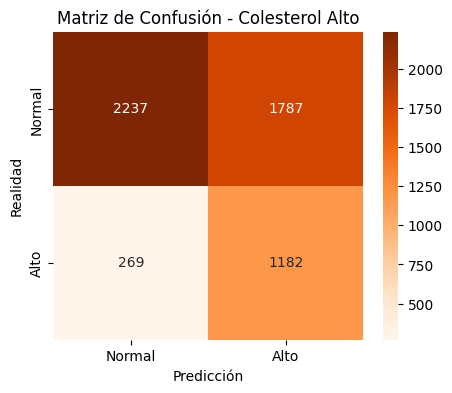


🔍 Variables que más delatan al Colesterol Alto:
           Variable  Importancia
               Edad     0.488401
         Cintura_cm     0.175531
            Peso_kg     0.092894
                IMC     0.089597
Riesgo_Hipertension     0.062574
        Estatura_cm     0.059199
             Genero     0.016187
            Fumador     0.015616


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("🩸 Preparando el dataset para clasificar Colesterol Alto...\n")

# 1. CARGAR DATOS
ruta_archivo = "../data/02_intermediate/df_nhanes_limpio.csv"
df = pd.read_csv(ruta_archivo)

# 2. CREAR LA VARIABLE OBJETIVO (INGENIERÍA DE CARACTERÍSTICAS)
# Si el colesterol es mayor a 200 mg/dL -> 1 (Alto), si no -> 0 (Normal)
df['Colesterol_Alto'] = (df['Colesterol_Total'] > 200).astype(int)

# 3. SEPARAR VARIABLES
# Eliminamos el 'Colesterol_Total' original para que el modelo no haga trampa
X = df.drop(columns=['Colesterol_Total', 'Colesterol_Alto'])
y = df['Colesterol_Alto']

print(f"📊 Total de pacientes analizados: {df.shape[0]}")
print(f"⚖️ Balance de clases (0 = Normal, 1 = Alto):\n{y.value_counts(normalize=True) * 100}\n")
print("---" * 15)

# 4. DIVIDIR EL DATASET (80% Entrenamiento, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. ENTRENAR EL MODELO
print("🧠 Entrenando Random Forest Classifier...")
# Usamos class_weight='balanced' por si las clases no están 50/50
modelo_colesterol = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=42)
modelo_colesterol.fit(X_train, y_train)

# 6. EVALUAR EN EL EXAMEN TEST
preds = modelo_colesterol.predict(X_test)

print("\n🏆 REPORTE DE CLASIFICACIÓN (COLESTEROL ALTO):")
print(classification_report(y_test, preds))

# 7. MATRIZ DE CONFUSIÓN VISUAL
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Normal', 'Alto'], yticklabels=['Normal', 'Alto'])
plt.title('Matriz de Confusión - Colesterol Alto')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# 8. VARIABLES MÁS IMPORTANTES
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_colesterol.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\n🔍 Variables que más delatan al Colesterol Alto:")
print(importancias.to_string(index=False))

[06/23/26 16:06:35] WARNING  C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\tqdm\ ]8;id=14043672;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=14043673;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             auto.py:21: TqdmWarning: IProgress not found. Please update jupyter                   
                             and ipywidgets. See                                                                   
                             https://ipywidgets.readthedocs.io/en/stable/user_install.html                         
                               from .autonotebook import tqdm as notebook_tqdm                                     
                                                                                                                   

🚀 Cargando datos reales...
🕵️‍♂️ Iniciando la búsqueda con Optuna (Optimizando XGBoost)...
✅ ¡Optimización terminada!
🏆 Mejor F1-Score alcanzado: 0.5438
⚙️ Mejores hiperparámetros encontrados: {'n_estimators': 76, 'max_depth': 4, 'learning_rate': 0.07833584729893792, 'subsample': 0.6086935424297231, 'colsample_bytree': 0.6532700972673361, 'scale_pos_weight': 2.3879024360275656}
--------------------------------------------------
🧠 Entrenando el modelo definitivo de XGBoost...

🏆 REPORTE DE CLASIFICACIÓN FINAL (XGBOOST OPTIMIZADO):
              precision    recall  f1-score   support

           0       0.88      0.64      0.74      4024
           1       0.43      0.75      0.54      1451

    accuracy                           0.67      5475
   macro avg       0.65      0.69      0.64      5475
weighted avg       0.76      0.67      0.69      5475



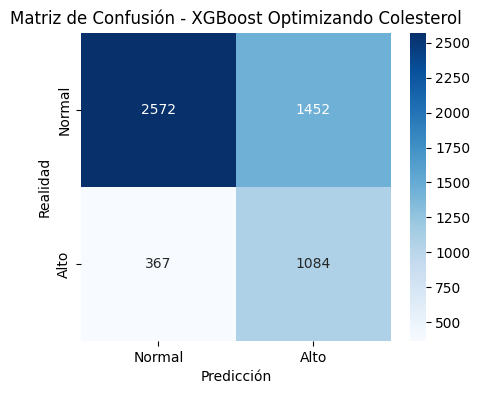


🔍 Importancia de Variables según XGBoost:
           Variable  Importancia
               Edad     0.419083
Riesgo_Hipertension     0.153611
             Genero     0.129329
         Cintura_cm     0.110051
                IMC     0.059882
        Estatura_cm     0.045838
            Peso_kg     0.042748
            Fumador     0.039458


In [7]:
import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Desactivar los mensajes repetitivos de Optuna para que la pantalla quede limpia
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("🚀 Cargando datos reales...")
ruta_archivo = "../data/02_intermediate/df_nhanes_limpio.csv"
df = pd.read_csv(ruta_archivo)

# Crear objetivo binario
df['Colesterol_Alto'] = (df['Colesterol_Total'] > 200).astype(int)

# Separar X e y
X = df.drop(columns=['Colesterol_Total', 'Colesterol_Alto'])
y = df['Colesterol_Alto']

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calcular el factor de desbalanceo para XGBoost (Sanos / Alti)
ratio_desbalance = (len(y_train) - sum(y_train)) / sum(y_train)

print("🕵️‍♂️ Iniciando la búsqueda con Optuna (Optimizando XGBoost)...")

# 1. Definir la función objetivo que Optuna va a intentar maximizar
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, ratio_desbalance),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    
    # Entrenar un modelo temporal para este intento
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Evaluar con F1-Score de la clase 1 (Colesterol Alto)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

# 2. Crear el estudio y ejecutar los experimentos
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # Hace 20 iteraciones inteligentes

print(f"✅ ¡Optimización terminada!")
print(f"🏆 Mejor F1-Score alcanzado: {study.best_value:.4f}")
print("⚙️ Mejores hiperparámetros encontrados:", study.best_params)
print("-" * 50)

# 3. Entrenar el modelo FINAL con los mejores parámetros descubiertos
print("🧠 Entrenando el modelo definitivo de XGBoost...")
mejor_modelo = xgb.XGBClassifier(**study.best_params, random_state=42)
mejor_modelo.fit(X_train, y_train)

# 4. Evaluación Final
preds_finales = mejor_modelo.predict(X_test)

print("\n🏆 REPORTE DE CLASIFICACIÓN FINAL (XGBOOST OPTIMIZADO):")
print(classification_report(y_test, preds_finales))

# 5. Gráfico de la Matriz de Confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds_finales), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Alto'], yticklabels=['Normal', 'Alto'])
plt.title('Matriz de Confusión - XGBoost Optimizando Colesterol')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# 6. Importancia de Variables del nuevo modelo
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': mejor_modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\n🔍 Importancia de Variables según XGBoost:")
print(importancias.to_string(index=False))